In [ ]:
"""
MLP classifier trained on the 60GeV runs with bias as input feature.

A flatten + 3-layer fully-connected counterpart to CNN_Classifier_60GeV.ipynb:
identical data pipeline and evaluation, but the (3, 64, 38) input is flattened
and fed through dense layers instead of convolutions. Trained with
BCEWithLogitsLoss (a single logit + fused sigmoid).
"""


In [1]:
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import re
import copy
import uproot
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, confusion_matrix
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader, Subset


def find_project_root(marker="Data", start=None):
    """Walk up from `start` (default: cwd) until we find a directory containing `marker`."""
    p = (start or Path.cwd()).resolve()
    for candidate in [p, *p.parents]:
        if (candidate / marker).is_dir():
            return candidate
    raise FileNotFoundError(f"Could not find '{marker}' starting from {p}")

PROJECT_ROOT = find_project_root("Data")
DATA_DIR     = PROJECT_ROOT / "Data"
LABELS_CSV   = DATA_DIR / "runs.csv"
print("project root:", PROJECT_ROOT)


project root: /Users/prometheus/Documents/Python/ML_FoCal_FinalProject


In [2]:
# data loading
labels_df = pd.read_csv(LABELS_CSV)
# Keep only the 60 GeV runs with non-zero bias (the new e/h dataset).
runs_df = labels_df.query("energy_GeV == 60 and bias_V > 0").copy()
print("runs to load:")
print(runs_df.to_string(index=False))

def find_root_file(run, data_dir=DATA_DIR):
    """Match either RunXXXX.root or RunXXX_EventMatch.root naming."""
    candidates = list(data_dir.glob(f"Run{run}*.root")) + list(data_dir.glob(f"Run{run:04d}*.root"))
    if not candidates:
        raise FileNotFoundError(f"No ROOT file for run {run}")
    return candidates[0]

val_chunks, run_ids, parts, biases = [], [], [], []
for _, row in runs_df.iterrows():
    f = find_root_file(int(row["run"]))
    t = uproot.open(f)["data_tree"]
    n = t.num_entries

    a0 = t["val0_list_0"].array(library="np").reshape(-1, 64, 38)
    a1 = t["val0_list_1"].array(library="np").reshape(-1, 64, 38)
    val_chunks.append(np.stack([a0, a1], axis=1))

    run_ids.append(np.full(n, int(row["run"]),     dtype=np.int32))
    parts.append(  np.full(n, row["particle"],     dtype="U1"))
    biases.append( np.full(n, int(row["bias_V"]),  dtype=np.int32))
    print(f"  Run{row.run:03d}: {n:6d} events  ({row.particle}, {row.bias_V}V)")

val0     = np.concatenate(val_chunks, axis=0)
run_id   = np.concatenate(run_ids)
particle = np.concatenate(parts)
bias_v   = np.concatenate(biases)
del val_chunks, run_ids, parts, biases

print(f"\ntotal events: {val0.shape[0]}  shape: {val0.shape}  ({val0.nbytes / 1e9:.2f} GB)")


runs to load:
 run  energy_GeV particle  bias_V
 577          60        h      43
 578          60        h      43
 579          60        h      45
 580          60        h      45
 603          60        e      45
 604          60        e      45
 605          60        e      43
 606          60        e      43
 607          60        e      43
  Run577:  17621 events  (h, 43V)
  Run578:  22362 events  (h, 43V)
  Run579:  20390 events  (h, 45V)
  Run580:  19992 events  (h, 45V)
  Run603:   3432 events  (e, 45V)
  Run604:  10275 events  (e, 45V)
  Run605:  17010 events  (e, 43V)
  Run606:  18581 events  (e, 43V)
  Run607:  17227 events  (e, 43V)

total events: 146890  shape: (146890, 2, 38, 64)  (2.86 GB)


### Data shape

Loaded as `val0` with shape `(N, 2, 64, 38)`:

| Dim | Size | Meaning |
|-----|------|---------|
| 0   | N    | event index (one event = one trigger) |
| 1   | 2    | detector halves: `h0`, `h1` |
| 2   | 64   | chips per half |
| 3   | 38   | readout channels per chip |

Parallel label arrays of length N: `run_id`, `particle` (`'e'`/`'h'`), `bias_v` (43/45).

The bias channel that turns this into `(N, 3, 64, 38)` is added later, after pedestal normalization, before training.


val0 shape: (146890, 2, 38, 64)  dtype: uint32
value range: 0 .. 1023
mean: 102.0  nonzero fraction: 0.974

events per (particle, bias):
                 n_events  n_runs
particle bias_V                  
e        43         52818       3
         45         13707       2
h        43         39983       2
         45         40382       2


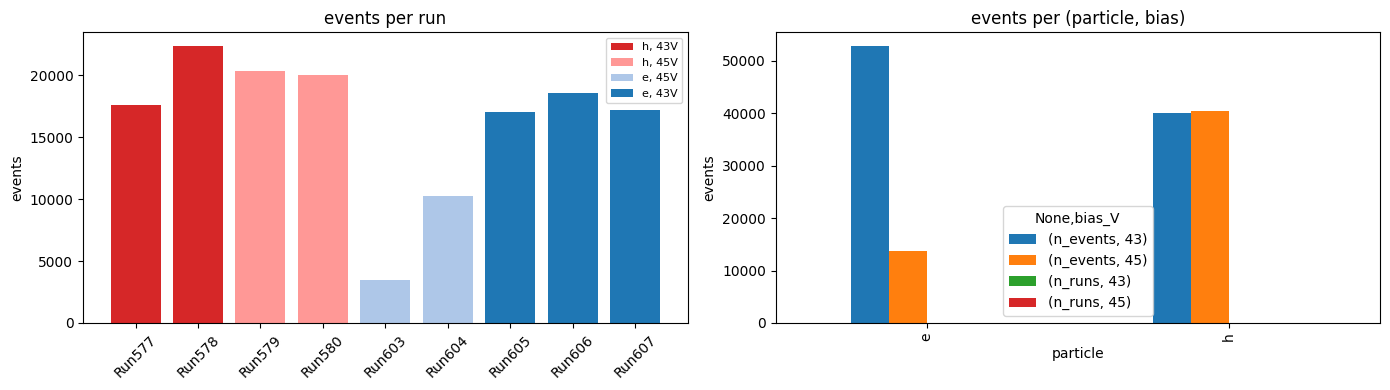

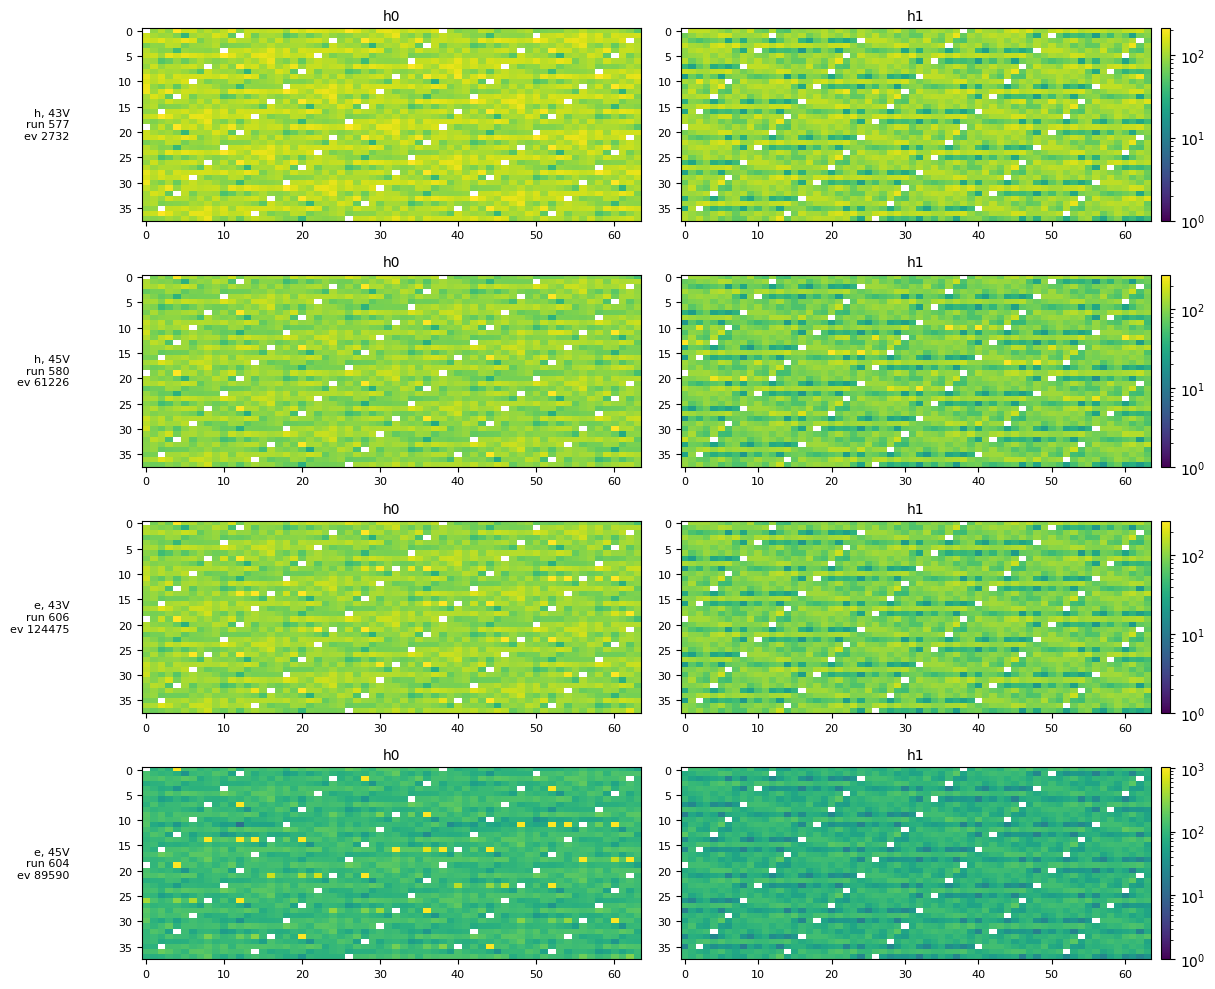

In [3]:
# Visualisation of the data (size and type and so on)
print(f"val0 shape: {val0.shape}  dtype: {val0.dtype}")
print(f"value range: {val0.min()} .. {val0.max()}")
print(f"mean: {val0.mean():.1f}  nonzero fraction: {(val0 > 0).mean():.3f}")

# Counts per (particle, bias) cell
summary = (pd.DataFrame({"particle": particle, "bias_V": bias_v, "run": run_id})
           .groupby(["particle", "bias_V"])
           .agg(n_events=("run", "size"), n_runs=("run", "nunique")))
print("\nevents per (particle, bias):")
print(summary)

# Bar chart: events per run, colored by (particle, bias)
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
df = pd.DataFrame({"run": run_id, "particle": particle, "bias_V": bias_v})
counts = df.groupby(["run", "particle", "bias_V"]).size().reset_index(name="n")
colors = {("e", 43): "#1f77b4", ("e", 45): "#aec7e8",
          ("h", 43): "#d62728", ("h", 45): "#ff9896"}
for (_, row), x in zip(counts.iterrows(), range(len(counts))):
    ax[0].bar(x, row.n, color=colors[(row.particle, row.bias_V)],
              label=f"{row.particle}, {row.bias_V}V")
ax[0].set_xticks(range(len(counts)))
ax[0].set_xticklabels([f"Run{r:03d}" for r in counts.run], rotation=45)
ax[0].set_ylabel("events"); ax[0].set_title("events per run")
# Dedupe legend
handles, labels = ax[0].get_legend_handles_labels()
seen = {}
for h, l in zip(handles, labels): seen.setdefault(l, h)
ax[0].legend(seen.values(), seen.keys(), fontsize=8)

# Stacked: events per (particle, bias)
summary.unstack("bias_V").plot.bar(ax=ax[1], stacked=False)
ax[1].set_ylabel("events"); ax[1].set_title("events per (particle, bias)")
plt.tight_layout(); plt.show()

# One example event per (particle, bias) cell -- both halves
from matplotlib.colors import LogNorm
groups = [("h", 43), ("h", 45), ("e", 43), ("e", 45)]
fig, ax = plt.subplots(len(groups), 2, figsize=(12, 2.5 * len(groups)), squeeze=False)
rng = np.random.RandomState(0)
for gi, (p, b) in enumerate(groups):
    mask = (particle == p) & (bias_v == b)
    idx  = rng.choice(np.where(mask)[0])
    ev   = val0[idx]
    vmax = max(int(np.percentile(ev, 99.5)), 2)
    for h in range(2):
        im = ax[gi, h].imshow(ev[h], aspect="auto", cmap="viridis",
                              norm=LogNorm(vmin=1, vmax=vmax))
        ax[gi, h].set_title(f"h{h}", fontsize=10)
        ax[gi, h].tick_params(labelsize=8)
    plt.colorbar(im, ax=ax[gi, 1], fraction=0.04, pad=0.02)
    ax[gi, 0].set_ylabel(f"{p}, {b}V\nrun {run_id[idx]}\nev {idx}",
                         rotation=0, ha="right", va="center", labelpad=35, fontsize=8)
plt.tight_layout(); plt.subplots_adjust(left=0.10); plt.show()


In [4]:
""" Pedestal normalization (computed separately per bias voltage)
For each bias, take the quietest 50% of events by total ADC -- those are mostly noise/pedestal events. 
Use them to compute per-channel mean and std. Apply z-score normalization to all events of that bias.
"""

event_sum = val0.sum(axis=(1, 2, 3))

pedestals = {}  # bias -> (mean (2,64,38), std (2,64,38))
for b in np.unique(bias_v):
    in_bias = bias_v == b
    cutoff  = np.percentile(event_sum[in_bias], 50)
    quiet   = in_bias & (event_sum < cutoff)
    mean    = val0[quiet].mean(axis=0).astype(np.float32)
    std     = val0[quiet].std(axis=0).astype(np.float32)
    pedestals[int(b)] = (mean, std)
    print(f"bias {b}V: {quiet.sum():6d} quiet events used  "
          f"mean ADC {mean.min():.1f}..{mean.max():.1f}  "
          f"avg std {std.mean():.2f}")

# Apply normalization (in place per-bias slice to avoid building a 2x-size copy)
val0_norm = np.empty(val0.shape, dtype=np.float32)
for b, (mean, std) in pedestals.items():
    m = bias_v == b
    val0_norm[m] = (val0[m].astype(np.float32) - mean) / (std + 1e-3)

print(f"\nnormalized: shape={val0_norm.shape}  dtype={val0_norm.dtype}  "
      f"memory={val0_norm.nbytes / 1e9:.2f} GB")
print(f"mean: {val0_norm.mean():+.3f}  (should be ~0 since most events are quiet)")
print(f"std : {val0_norm.std():.3f}  (close to 1 if normalization is sane)")


bias 43V:  46394 quiet events used  mean ADC 0.0..1023.0  avg std 3.14
bias 45V:  27042 quiet events used  mean ADC 0.0..1023.0  avg std 5.27

normalized: shape=(146890, 2, 38, 64)  dtype=float32  memory=2.86 GB
mean: +0.059  (should be ~0 since most events are quiet)
std : 1.229  (close to 1 if normalization is sane)


In [5]:
"""
Build the model input tensor and 3-way train / val / test split.

Input shape: (N, 3, 64, 38)
  - channels 0,1: pedestal-normalized detector halves (val0_norm)
  - channel  2:  broadcasted bias indicator (43V -> -1, 45V -> +1)
Labels: int64 (N,), 0 = hadron, 1 = electron.

Splits, all stratified on (particle, bias):
  - train (70%): fit model weights
  - val   (15%): early stopping and monitoring during training
  - test  (15%): final per-event evaluation. Looked at ONCE at the end --
                 never used to make any modeling decision.

The per-run holdout sanity check (model evaluated on whole runs never seen
during training) comes later as a separate, independent evaluation.
"""

# 3-channel input: 2 normalized halves + 1 bias channel
bias_norm = (bias_v.astype(np.float32) - 44.0)  # 43 -> -1, 45 -> +1
bias_ch   = np.broadcast_to(bias_norm[:, None, None, None],
                            (len(val0_norm), 1, 64, 38)).astype(np.float32)
x_tensor  = np.concatenate([val0_norm, bias_ch], axis=1)
y_tensor  = (particle == "e").astype(np.int64)

print(f"x: {x_tensor.shape}  {x_tensor.nbytes / 1e9:.2f} GB")
print(f"y: {y_tensor.shape}  label counts: "
      f"{dict(zip(['h', 'e'], np.bincount(y_tensor)))}")

# Stratification key combines particle and bias so each cell is represented in
# all three splits in the same proportion as the full dataset
strat = np.array([f"{p}_{b}" for p, b in zip(particle, bias_v)])

# First split: separate off 15% for the test set
idx_trainval, idx_test = train_test_split(
    np.arange(len(x_tensor)),
    test_size=0.15,
    stratify=strat,
    random_state=0,
)
# Second split: from the remaining 85%, take ~17.6% as val -> 15% of the whole
idx_train, idx_val = train_test_split(
    idx_trainval,
    test_size=0.15 / 0.85,
    stratify=strat[idx_trainval],
    random_state=0,
)
print(f"\nsplit sizes:  train {len(idx_train)}  val {len(idx_val)}  test {len(idx_test)}")
for name, idx in [("  train", idx_train), ("  val  ", idx_val), ("  test ", idx_test)]:
    counts = {k: int((strat[idx] == k).sum()) for k in sorted(np.unique(strat))}
    print(f"{name}: {counts}")

# Wrap as TensorDataset + Subset for each split
ds = TensorDataset(torch.from_numpy(x_tensor), torch.from_numpy(y_tensor))
train_ds = Subset(ds, idx_train)
val_ds   = Subset(ds, idx_val)
test_ds  = Subset(ds, idx_test)  # set aside, do not peek

BATCH = 256
train_loader = DataLoader(train_ds, batch_size=BATCH,     shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH * 2, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH * 2, shuffle=False, num_workers=0)

# Smoke test
xb, yb = next(iter(train_loader))
print(f"\nbatch x: {tuple(xb.shape)} {xb.dtype}   y: {tuple(yb.shape)} {yb.dtype}")
print(f"bias channel values in batch: {torch.unique(xb[:, 2]).tolist()}")


x: (146890, 3, 38, 64)  4.29 GB
y: (146890,)  label counts: {'h': np.int64(80365), 'e': np.int64(66525)}

split sizes:  train 102822  val 22034  test 22034
  train: {np.str_('e_43'): 36972, np.str_('e_45'): 9595, np.str_('h_43'): 27988, np.str_('h_45'): 28267}
  val  : {np.str_('e_43'): 7923, np.str_('e_45'): 2056, np.str_('h_43'): 5997, np.str_('h_45'): 6058}
  test : {np.str_('e_43'): 7923, np.str_('e_45'): 2056, np.str_('h_43'): 5998, np.str_('h_45'): 6057}

batch x: (256, 3, 38, 64) torch.float32   y: (256,) torch.int64
bias channel values in batch: [-1.0, 1.0]


### MLP classifier architecture

About 1.9M parameters. Input shape `(B, 3, 64, 38)`, flattened to `(B, 7296)`,
output **1 logit** (electron score).

| Layer | Output shape | Notes |
|-------|-------------|-------|
| Input | `(B, 3, 64, 38)` | 2 normalized halves + 1 bias channel |
| Flatten | `(B, 7296)` | spatial structure discarded; every channel/chip/strip is one feature |
| Linear(7296→256) + BatchNorm + ReLU + Dropout(0.3) | `(B, 256)` | |
| Linear(256→64) + BatchNorm + ReLU + Dropout(0.3) | `(B, 64)` | |
| Linear(64→1) | `(B, 1)` → `(B,)` | single logit — apply sigmoid for P(electron) |

**Notes vs. the CNN:**

Flatten instead of convolution. The MLP has no notion of locality or
translation invariance — a shower at chip 5 and one at chip 25 are completely
unrelated inputs. This is the main thing the CNN buys you; the MLP is the
baseline that shows what you give up.

BatchNorm1d + Dropout(0.3) mirror the CNN's regularization so the comparison is
about architecture, not training tricks.

Single-logit head + `BCEWithLogitsLoss` instead of 2 logits + cross-entropy.
For binary classification the two are equivalent; this just follows the
requested loss.

In [6]:
"""
MLP classifier for hadron vs electron events.

The (3, 64, 38) input is flattened to a 7296-dim vector and pushed through a
3-layer fully-connected network. Spatial structure is discarded entirely.

Architecture (mirrors the CNN's depth + regularization):
- Flatten (3, 64, 38) -> 7296
- Linear(7296 -> 256) + BatchNorm1d + ReLU + Dropout(0.3)
- Linear(256  ->  64) + BatchNorm1d + ReLU + Dropout(0.3)
- Linear(64   ->   1) -> single logit

Input:  (B, 3, 64, 38) -- 2 normalized halves + 1 bias channel
Output: (B,) single logit; apply sigmoid for P(electron).
        Trained with BCEWithLogitsLoss (sigmoid + BCE fused).
"""

IN_FEATURES = 3 * 64 * 38  # 7296


class MLPClassifier(nn.Module):
    def __init__(self, in_features=IN_FEATURES):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),                 # (B, 3, 64, 38) -> (B, 7296)
            nn.Linear(in_features, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1),             # single logit
        )

    def forward(self, x):
        return self.net(x).squeeze(1)     # (B,)


device = ("cuda" if torch.cuda.is_available()
          else "mps" if torch.backends.mps.is_available()
          else "cpu")
model = MLPClassifier().to(device)

# Sanity check: forward pass on a dummy batch matches expected shape
with torch.no_grad():
    dummy = torch.zeros(2, 3, 64, 38, device=device)
    out = model(dummy)
    assert out.shape == (2,), out.shape
    print(f"output shape ok: {tuple(out.shape)}")

print(f"\ndevice: {device}   params: {sum(p.numel() for p in model.parameters()):,}")
print(model)


output shape ok: (2,)

device: mps   params: 1,885,185
MLPClassifier(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=7296, out_features=256, bias=True)
    (2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ReLU()
    (4): Dropout(p=0.3, inplace=False)
    (5): Linear(in_features=256, out_features=64, bias=True)
    (6): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU()
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=64, out_features=1, bias=True)
  )
)


### Training pipeline

What the next cell does, in order:

1. **Optimizer**: `AdamW` with `weight_decay=1e-4`. Adam-style adaptive LR plus correctly-decoupled weight decay for mild regularization.
2. **Loss**: `BCEWithLogitsLoss` on the single output logit (fused sigmoid + binary cross-entropy — numerically stabler than sigmoid followed by BCE). Labels are cast to float (0 = hadron, 1 = electron).
3. **LR scheduler**: `ReduceLROnPlateau` — halves the learning rate when val loss hasn't improved for `LR_PATIENCE` epochs. Gives the model a smaller step size to escape a plateau before early stopping kicks in.
4. **Per-epoch loop**: full pass over `train_loader`, then evaluation pass over `val_loader`. Logs train/val loss and val accuracy.
5. **Early stopping**: if val loss hasn't improved by `MIN_DELTA` for `PATIENCE` epochs (where `PATIENCE > LR_PATIENCE`), stop and restore best-val-loss weights.
6. **Weight caching**: best weights are saved to `Rasmus/MLP_classifier_60GeV.pt`. On next run, loaded from disk unless `RETRAIN = True`.
7. **No test-set access** anywhere in this cell — that's locked behind its own cell at the end of the notebook.

In [ ]:
"""
Train the MLP classifier with early stopping and an LR scheduler.

- AdamW(weight_decay=1e-4) + BCEWithLogitsLoss on a single logit
- ReduceLROnPlateau halves LR after LR_PATIENCE epochs without improvement
- Early stop if no improvement for PATIENCE epochs (PATIENCE > LR_PATIENCE so
  the scheduler gets a chance to fire before training gives up)
- Best-val-loss weights restored and saved to disk; test set is not touched
"""

MAX_EPOCHS   = 100
PATIENCE     = 12      # epochs without val improvement -> stop training
LR_PATIENCE  = 4       # epochs without val improvement -> halve LR
MIN_DELTA    = 1e-4
LR           = 1e-3
WEIGHT_DECAY = 1e-4
RETRAIN      = False
CLASSIFIER_WEIGHTS = PROJECT_ROOT / "Rasmus" / "Classifier" /"MLP_classifier_60GeV.pt"

history = {"train_loss": [], "val_loss": [], "val_acc": [], "lr": []}

if CLASSIFIER_WEIGHTS.exists() and not RETRAIN:
    model.load_state_dict(torch.load(CLASSIFIER_WEIGHTS, map_location=device))
    print(f"loaded cached weights from {CLASSIFIER_WEIGHTS.name} (set RETRAIN=True to override)")
else:
    opt       = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt, mode="min", factor=0.5, patience=LR_PATIENCE, min_lr=1e-6,
    )
    loss_fn = nn.BCEWithLogitsLoss()

    best_val_loss = float("inf")
    best_epoch    = -1
    best_state    = copy.deepcopy(model.state_dict())
    bad_epochs    = 0

    for epoch in range(MAX_EPOCHS):
        # ---- train pass ----
        model.train()
        tr_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device).float()
            logits = model(xb)
            loss = loss_fn(logits, yb)
            opt.zero_grad(); loss.backward(); opt.step()
            tr_loss += loss.item() * xb.size(0)
        tr_loss /= len(train_ds)

        # ---- val pass ----
        model.eval()
        va_loss, correct = 0.0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                logits = model(xb)
                va_loss += loss_fn(logits, yb.float()).item() * xb.size(0)
                correct += ((logits > 0).long() == yb).sum().item()
        va_loss /= len(val_ds)
        va_acc   = correct / len(val_ds)

        # ---- scheduler step + bookkeeping ----
        scheduler.step(va_loss)
        cur_lr = opt.param_groups[0]["lr"]

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)
        history["lr"].append(cur_lr)

        improved = va_loss < best_val_loss - MIN_DELTA
        if improved:
            best_val_loss = va_loss
            best_epoch    = epoch
            best_state    = copy.deepcopy(model.state_dict())
            bad_epochs    = 0
            tag = " *"
        else:
            bad_epochs += 1
            tag = ""
        print(f"epoch {epoch+1:3d}/{MAX_EPOCHS}  "
              f"train={tr_loss:.4f}  val_loss={va_loss:.4f}  val_acc={va_acc:.3f}  "
              f"lr={cur_lr:.1e}  bad={bad_epochs}{tag}")

        if bad_epochs >= PATIENCE:
            print(f"\nearly stop at epoch {epoch+1}: no improvement for {PATIENCE} epochs")
            break

    # Restore best weights and persist them
    model.load_state_dict(best_state)
    torch.save(best_state, CLASSIFIER_WEIGHTS)
    print(f"\nbest val_loss={best_val_loss:.4f}  "
          f"val_acc={history['val_acc'][best_epoch]:.3f} at epoch {best_epoch+1}")
    print(f"saved {CLASSIFIER_WEIGHTS}")


epoch   1/100  train=0.0643  val_loss=0.0181  val_acc=0.994  lr=1.0e-03  bad=0 *
epoch   2/100  train=0.0172  val_loss=0.0176  val_acc=0.995  lr=1.0e-03  bad=0 *
epoch   3/100  train=0.0123  val_loss=0.0221  val_acc=0.993  lr=1.0e-03  bad=1
epoch   4/100  train=0.0108  val_loss=0.0176  val_acc=0.994  lr=1.0e-03  bad=2
epoch   5/100  train=0.0097  val_loss=0.0209  val_acc=0.993  lr=1.0e-03  bad=3
epoch   6/100  train=0.0079  val_loss=0.0288  val_acc=0.991  lr=1.0e-03  bad=4
epoch   7/100  train=0.0066  val_loss=0.0169  val_acc=0.995  lr=1.0e-03  bad=0 *
epoch   8/100  train=0.0065  val_loss=0.0199  val_acc=0.994  lr=1.0e-03  bad=1
epoch   9/100  train=0.0055  val_loss=0.0191  val_acc=0.995  lr=1.0e-03  bad=2
epoch  10/100  train=0.0048  val_loss=0.0172  val_acc=0.995  lr=1.0e-03  bad=3
epoch  11/100  train=0.0054  val_loss=0.0181  val_acc=0.994  lr=1.0e-03  bad=4
epoch  12/100  train=0.0043  val_loss=0.0185  val_acc=0.995  lr=5.0e-04  bad=5
epoch  13/100  train=0.0026  val_loss=0.0183  

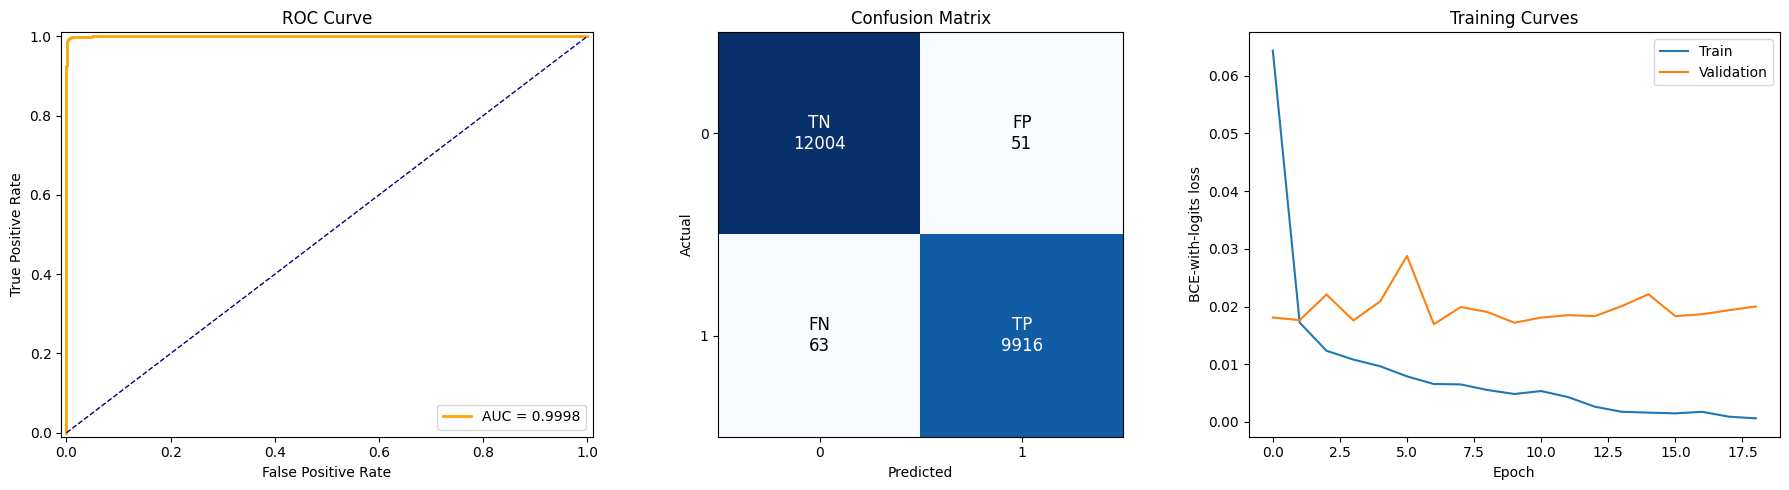

val accuracy:  0.9948
val AUC:       0.9998
confusion matrix (rows=actual, cols=predicted):
      pred=h  pred=e
act=h   12004      51
act=e      63    9916


In [8]:
"""
Evaluate the trained classifier on the validation set.

Three plots side by side:
- ROC curve with AUC for the electron class
- Confusion matrix with TN/FP/FN/TP cells
- Training curves (skipped if model was loaded from cache)

Plus a printed summary: val accuracy, AUC, and the raw confusion matrix.
"""

# Collect val predictions
model.eval()
probs_list, labels_list = [], []
with torch.no_grad():
    for xb, yb in val_loader:
        xb = xb.to(device)
        logits = model(xb)
        probs  = torch.sigmoid(logits)               # P(electron)
        probs_list.append(probs.cpu().numpy())
        labels_list.append(yb.numpy())
y_prob = np.concatenate(probs_list)
y_true = np.concatenate(labels_list)
y_pred = (y_prob > 0.5).astype(int)

fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc     = auc(fpr, tpr)
cm          = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()

# Plot
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# --- ROC ---
ax[0].plot(fpr, tpr, color="orange", lw=2, label=f"AUC = {roc_auc:.4f}")
ax[0].plot([0, 1], [0, 1], "--", color="navy", lw=1)
ax[0].set_xlabel("False Positive Rate"); ax[0].set_ylabel("True Positive Rate")
ax[0].set_title("ROC Curve"); ax[0].legend(loc="lower right")
ax[0].set_xlim(-0.01, 1.01); ax[0].set_ylim(-0.01, 1.01)

# --- Confusion matrix ---
ax[1].imshow(cm, cmap="Blues")
ax[1].set_xticks([0, 1]); ax[1].set_yticks([0, 1])
ax[1].set_xlabel("Predicted"); ax[1].set_ylabel("Actual")
ax[1].set_title("Confusion Matrix")
cell_labels = [["TN", "FP"], ["FN", "TP"]]
for i in range(2):
    for j in range(2):
        val = cm[i, j]
        ax[1].text(j, i, f"{cell_labels[i][j]}\n{val}", ha="center", va="center",
                   color="white" if val > cm.max() / 2 else "black", fontsize=12)

# --- Training curves (only if we have history) ---
if history["train_loss"]:
    ax[2].plot(history["train_loss"], label="Train")
    ax[2].plot(history["val_loss"],   label="Validation")
    ax[2].set_xlabel("Epoch"); ax[2].set_ylabel("BCE-with-logits loss")
    ax[2].set_title("Training Curves"); ax[2].legend()
else:
    ax[2].text(0.5, 0.5, "no training history\n(loaded from cache)",
               ha="center", va="center", transform=ax[2].transAxes, fontsize=11)
    ax[2].set_xticks([]); ax[2].set_yticks([])
    ax[2].set_title("Training Curves")

plt.tight_layout(); plt.show()

# Numerical summary
print(f"val accuracy:  {(y_pred == y_true).mean():.4f}")
print(f"val AUC:       {roc_auc:.4f}")
print(f"confusion matrix (rows=actual, cols=predicted):")
print(f"      pred=h  pred=e")
print(f"act=h  {tn:6d}  {fp:6d}")
print(f"act=e  {fn:6d}  {tp:6d}")


### Interpretability: SHAP and permutation importance

The CNN used Grad-CAM, which needs spatial conv feature maps. The MLP has none
(it flattens the input first), so we use two model-appropriate tools instead.
Both produce attributions that share the `(3, 64, 38)` input shape, so they can
be reshaped back onto the detector geometry and shown next to the raw inputs.

**SHAP (local, per-event).** For each `(particle, bias)` cell we pick a
high-confidence correctly-classified event and attribute the model's logit to
each input feature with `shap.GradientExplainer`. Positive (red) pushes toward
**electron**, negative (blue) toward **hadron**. This is the closest analogue
to the per-event Grad-CAM panels.

**Permutation importance (global, model-agnostic).** For each input feature we
shuffle its values across a val subset and measure how much accuracy drops. A
large drop means the model leans on that feature. Reshaped to the detector grid
it shows *which regions* matter overall, not just for one event.

**Interpretation guide:**

- **Compact bright SHAP / importance region** → model locks onto a localized,
  shower-shaped feature. Consistent with real physics.
- **Diffuse / scattered** → distributed channel-level patterns. Could be real,
  or a run-fingerprint shortcut (specific dead/noisy channels).
- A large **bias-channel** attribution means the model leans on the bias
  indicator rather than the detector image.

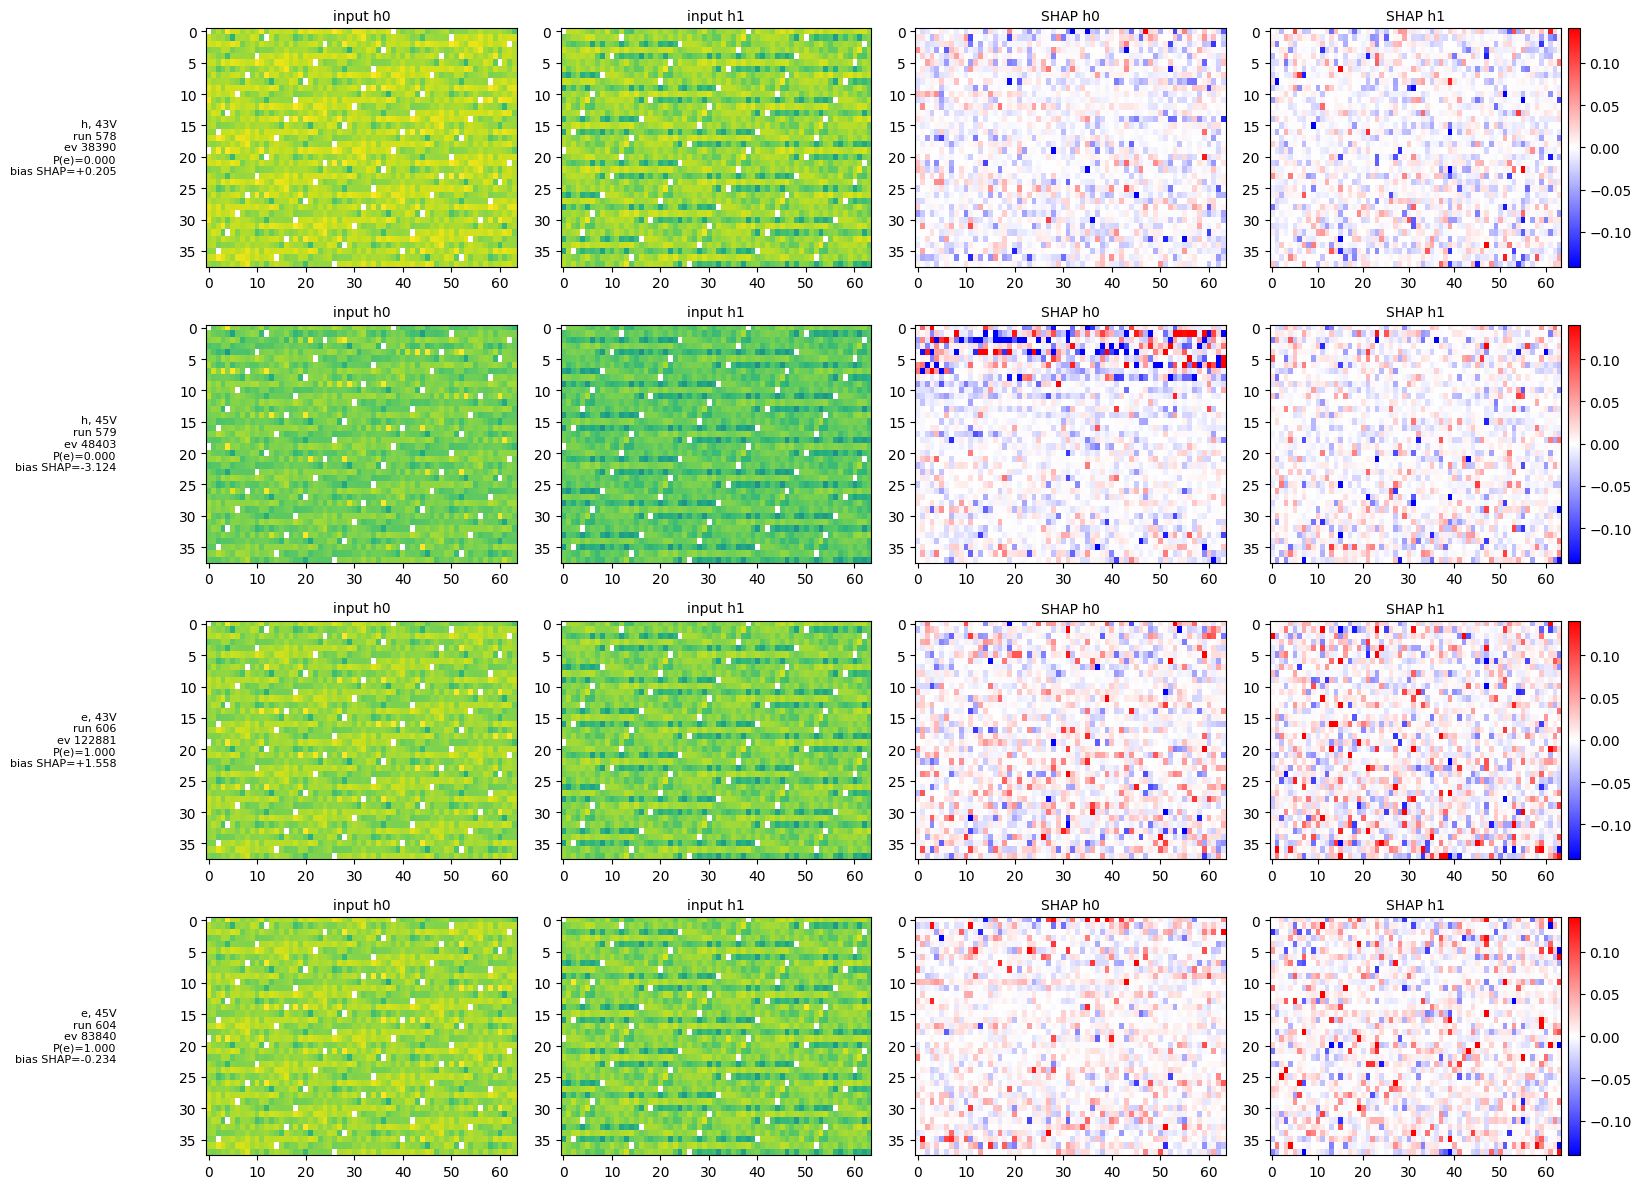

In [12]:
"""
SHAP attributions on high-confidence correctly-classified val events.

Grad-CAM needs conv feature maps the MLP doesn't have, so we attribute the
output logit to individual input features with shap.GradientExplainer. SHAP
values share the (3, 64, 38) input shape, so we reshape them onto the detector
geometry and plot them beside the raw inputs:
  positive (red)  -> pushes toward electron
  negative (blue) -> pushes toward hadron
"""
import shap
from matplotlib.colors import LogNorm

# GradientExplainer indexes the model output as outputs[:, idx], so it needs a
# 2-D output (B, n_outputs). The MLP squeezes to (B,), so wrap it to keep a
# (B, 1) output. Run on CPU -- the explainer + MPS can be flaky.
class _TwoDimOut(nn.Module):
    def __init__(self, m):
        super().__init__()
        self.m = m

    def forward(self, x):
        return self.m(x).reshape(-1, 1)  # (B, 1)

shap_model = _TwoDimOut(copy.deepcopy(model).to("cpu").eval()).eval()

rng = np.random.RandomState(0)
bg_idx     = rng.choice(idx_train, size=200, replace=False)
background = torch.from_numpy(x_tensor[bg_idx])
explainer  = shap.GradientExplainer(shap_model, background)

# Align val predictions with val_ds indices
val_indices  = np.asarray(val_ds.indices)
val_particle = particle[val_indices]
val_bias_v   = bias_v[val_indices]
val_y        = y_tensor[val_indices]

model.eval()
val_probs = np.empty(len(val_indices), dtype=np.float32)
cursor = 0
with torch.no_grad():
    for xb, _ in val_loader:
        xb = xb.to(device)
        p = torch.sigmoid(model(xb)).cpu().numpy()
        val_probs[cursor:cursor + len(p)] = p
        cursor += len(p)
val_preds   = (val_probs > 0.5).astype(int)
val_correct = val_preds == val_y

# One high-confidence correct event per (particle, bias) cell
groups = [("h", 43), ("h", 45), ("e", 43), ("e", 45)]
picks  = []  # positions into the val arrays (None if no correct event)
for p, b in groups:
    mask = (val_particle == p) & (val_bias_v == b) & val_correct
    if not mask.any():
        picks.append(None); continue
    cand  = np.where(mask)[0]
    # highest P(target class) among correct events of this cell
    score = val_probs[cand] if p == "e" else -val_probs[cand]
    picks.append(cand[np.argmax(score)])

sel_pos = [pp for pp in picks if pp is not None]
sel_idx = val_indices[sel_pos]
shap_vals = explainer.shap_values(torch.from_numpy(x_tensor[sel_idx]))
if isinstance(shap_vals, list):
    shap_vals = shap_vals[0]
shap_vals = np.asarray(shap_vals)
if shap_vals.ndim == 5:          # (n, 3, 64, 38, 1) for single output
    shap_vals = shap_vals[..., 0]
smax = np.percentile(np.abs(shap_vals[:, :2]), 99)  # symmetric color scale

fig, ax = plt.subplots(len(groups), 4, figsize=(16, 3 * len(groups)), squeeze=False)
si = 0
for gi, (p, b) in enumerate(groups):
    if picks[gi] is None:
        for j in range(4):
            ax[gi, j].text(0.5, 0.5, f"no correct {p}/{b}V events",
                           ha="center", va="center", transform=ax[gi, j].transAxes)
            ax[gi, j].set_xticks([]); ax[gi, j].set_yticks([])
        continue

    pos      = picks[gi]
    orig_idx = val_indices[pos]
    ev   = val0[orig_idx]
    vmax = max(int(np.percentile(ev, 99.5)), 2)
    norm = LogNorm(vmin=1, vmax=vmax)

    ax[gi, 0].imshow(ev[0], aspect="auto", cmap="viridis", norm=norm)
    ax[gi, 0].set_title("input h0", fontsize=10)
    ax[gi, 1].imshow(ev[1], aspect="auto", cmap="viridis", norm=norm)
    ax[gi, 1].set_title("input h1", fontsize=10)

    s = shap_vals[si]  # (3, 64, 38)
    ax[gi, 2].imshow(s[0], aspect="auto", cmap="bwr", vmin=-smax, vmax=smax)
    ax[gi, 2].set_title("SHAP h0", fontsize=10)
    im = ax[gi, 3].imshow(s[1], aspect="auto", cmap="bwr", vmin=-smax, vmax=smax)
    ax[gi, 3].set_title("SHAP h1", fontsize=10)
    plt.colorbar(im, ax=ax[gi, 3], fraction=0.04, pad=0.02)

    ax[gi, 0].set_ylabel(
        f"{p}, {b}V\nrun {run_id[orig_idx]}\nev {orig_idx}\n"
        f"P(e)={val_probs[pos]:.3f}\nbias SHAP={s[2].sum():+.3f}",
        rotation=0, ha="right", va="center", labelpad=45, fontsize=8,
    )
    si += 1

plt.tight_layout(); plt.subplots_adjust(left=0.10); plt.show()


  permuted 1000/7296 features
  permuted 2000/7296 features
  permuted 3000/7296 features
  permuted 4000/7296 features
  permuted 5000/7296 features
  permuted 6000/7296 features
  permuted 7000/7296 features


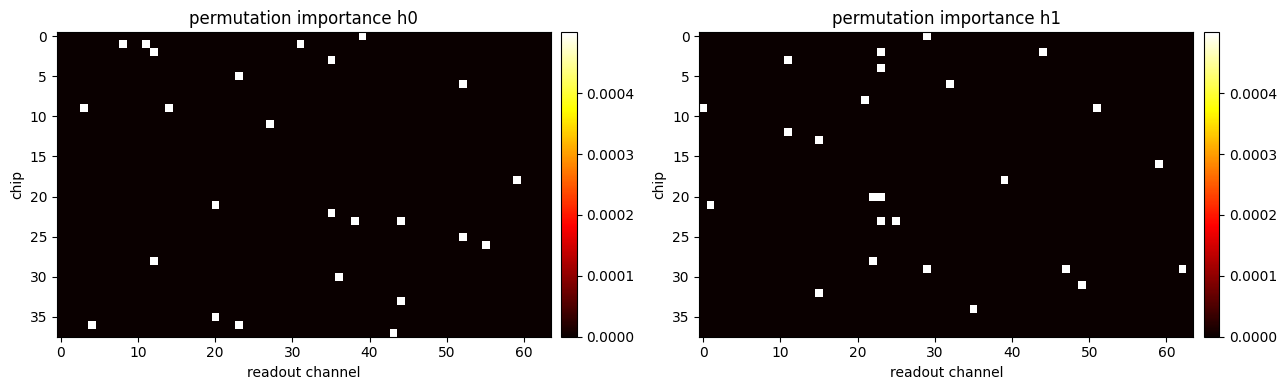

baseline val-subset accuracy: 0.9970  (n=2000)
detector-pixel importance:    max +0.00050  mean -0.000020
bias-channel mean importance: +0.000000


In [10]:
"""
Permutation importance on a val subset.

A global, model-agnostic complement to SHAP: for each input feature, shuffle
its values across events and measure how much val accuracy drops. A large drop
means the model relies on that feature. Importances share the (3, 64, 38) input
shape, so we reshape them onto the detector geometry.

Note: this permutes all 7296 features one at a time -> 7296 forward passes.
Reduce N_PI or subsample features if it's too slow on your machine.
"""

N_PI = 2000
rng  = np.random.RandomState(1)
pi_pos = rng.choice(len(val_indices), size=min(N_PI, len(val_indices)), replace=False)
X_pi = torch.from_numpy(x_tensor[val_indices[pi_pos]]).to(device)
y_pi = torch.from_numpy(y_tensor[val_indices[pi_pos]]).to(device)

model.eval()

@torch.no_grad()
def pi_acc(X):
    return ((model(X) > 0).long() == y_pi).float().mean().item()

base   = pi_acc(X_pi)
Xflat  = X_pi.reshape(len(X_pi), -1)        # view into X_pi
F      = Xflat.shape[1]
perm   = torch.randperm(len(X_pi), device=device)
importances = np.zeros(F, dtype=np.float32)

with torch.no_grad():
    for f in range(F):
        col = Xflat[:, f].clone()
        Xflat[:, f] = col[perm]             # shuffle this feature across events
        importances[f] = base - pi_acc(X_pi)
        Xflat[:, f] = col                   # restore
        if (f + 1) % 1000 == 0:
            print(f"  permuted {f + 1}/{F} features")

importances = importances.reshape(3, 64, 38)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
vmax = max(np.percentile(importances[:2], 99.5), 1e-6)
for h in range(2):
    im = ax[h].imshow(importances[h], aspect="auto", cmap="hot", vmin=0, vmax=vmax)
    ax[h].set_title(f"permutation importance h{h}")
    ax[h].set_xlabel("readout channel"); ax[h].set_ylabel("chip")
    plt.colorbar(im, ax=ax[h], fraction=0.04, pad=0.02)
plt.tight_layout(); plt.show()

print(f"baseline val-subset accuracy: {base:.4f}  (n={len(X_pi)})")
print(f"detector-pixel importance:    max {importances[:2].max():+.5f}  "
      f"mean {importances[:2].mean():+.6f}")
print(f"bias-channel mean importance: {importances[2].mean():+.6f}")


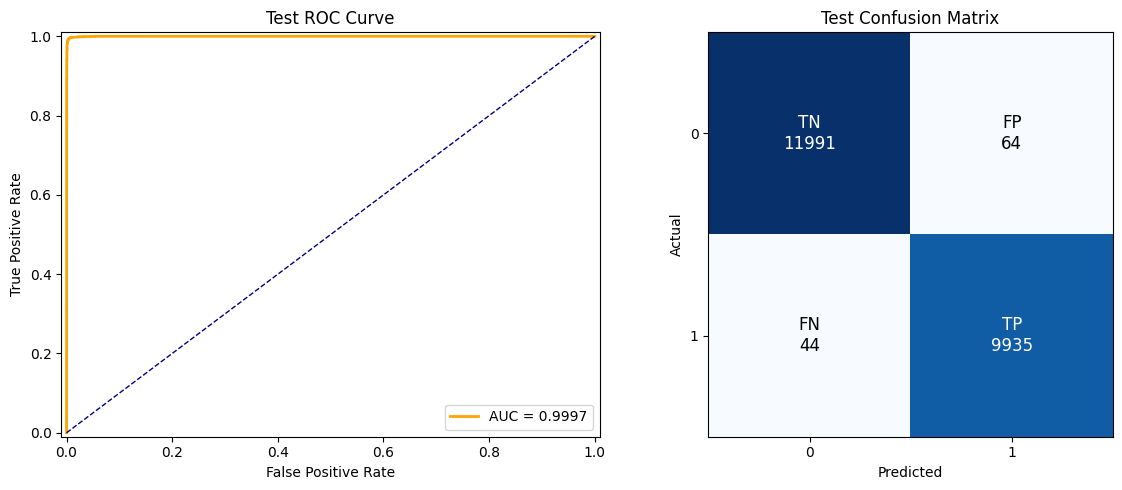

test accuracy:  0.9951
test AUC:       0.9997
confusion matrix (rows=actual, cols=predicted):
      pred=h  pred=e
act=h   11991      64
act=e      44    9935


In [11]:
"""
FINAL test-set evaluation.

The held-out 15% test split, never seen during training and never used for
model selection. Run this ONCE after you're done iterating on the model. If
you run it and then make a change based on what you see, it stops being a
test set and becomes another validation set.

Reports per-event accuracy, ROC + AUC, and confusion matrix on the test set.
"""

# Collect test predictions
model.eval()
probs_list, labels_list = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        logits = model(xb)
        probs  = torch.sigmoid(logits)               # P(electron)
        probs_list.append(probs.cpu().numpy())
        labels_list.append(yb.numpy())
y_prob = np.concatenate(probs_list)
y_true = np.concatenate(labels_list)
y_pred = (y_prob > 0.5).astype(int)

fpr, tpr, _   = roc_curve(y_true, y_prob)
roc_auc       = auc(fpr, tpr)
cm            = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# ROC
ax[0].plot(fpr, tpr, color="orange", lw=2, label=f"AUC = {roc_auc:.4f}")
ax[0].plot([0, 1], [0, 1], "--", color="navy", lw=1)
ax[0].set_xlabel("False Positive Rate"); ax[0].set_ylabel("True Positive Rate")
ax[0].set_title("Test ROC Curve"); ax[0].legend(loc="lower right")
ax[0].set_xlim(-0.01, 1.01); ax[0].set_ylim(-0.01, 1.01)

# Confusion matrix
ax[1].imshow(cm, cmap="Blues")
ax[1].set_xticks([0, 1]); ax[1].set_yticks([0, 1])
ax[1].set_xlabel("Predicted"); ax[1].set_ylabel("Actual")
ax[1].set_title("Test Confusion Matrix")
cell_labels = [["TN", "FP"], ["FN", "TP"]]
for i in range(2):
    for j in range(2):
        val = cm[i, j]
        ax[1].text(j, i, f"{cell_labels[i][j]}\n{val}", ha="center", va="center",
                   color="white" if val > cm.max() / 2 else "black", fontsize=12)

plt.tight_layout(); plt.show()

print(f"test accuracy:  {(y_pred == y_true).mean():.4f}")
print(f"test AUC:       {roc_auc:.4f}")
print(f"confusion matrix (rows=actual, cols=predicted):")
print(f"      pred=h  pred=e")
print(f"act=h  {tn:6d}  {fp:6d}")
print(f"act=e  {fn:6d}  {tp:6d}")
